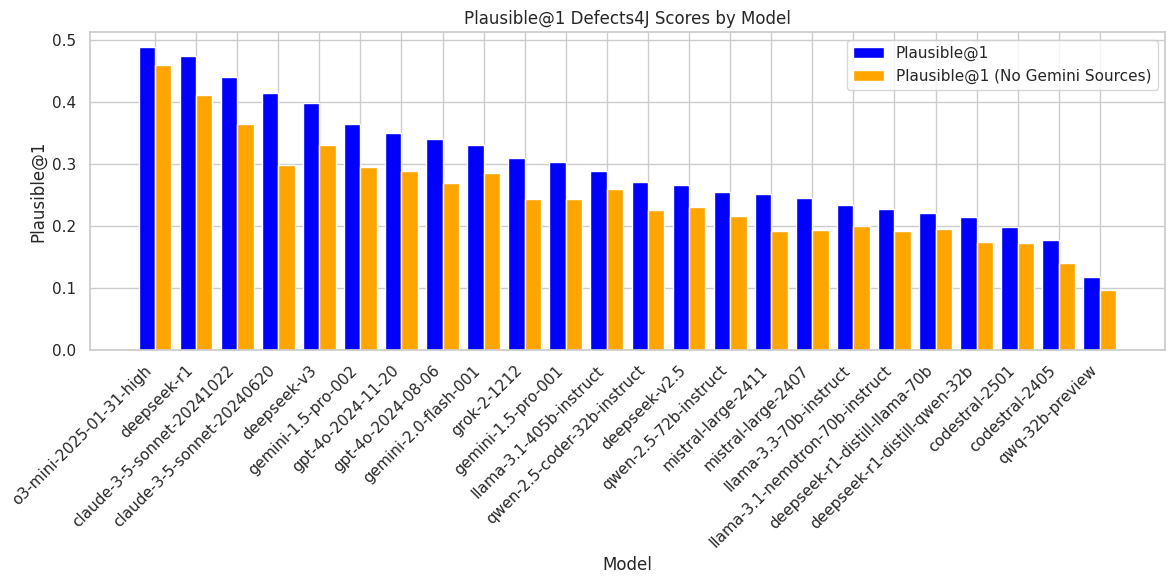

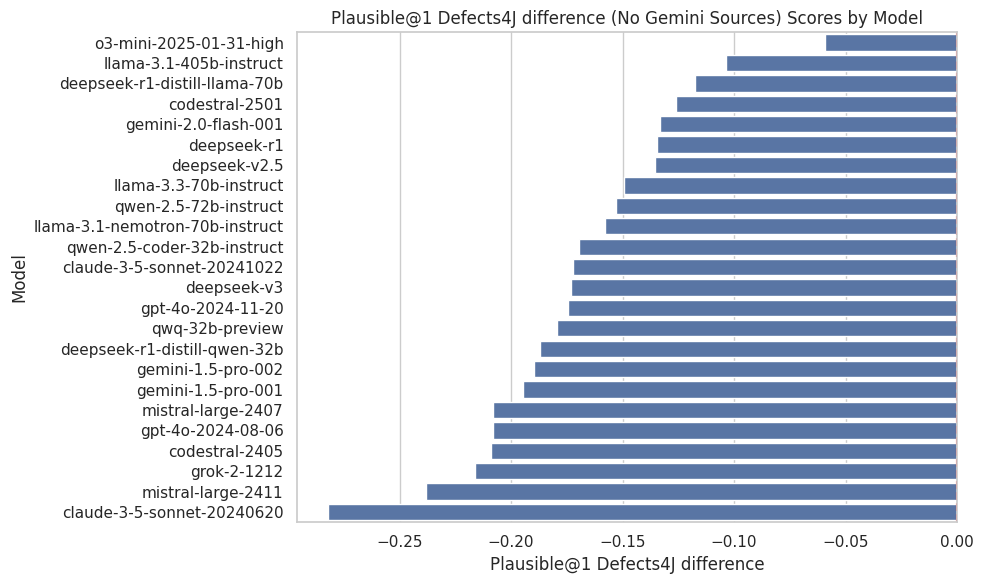

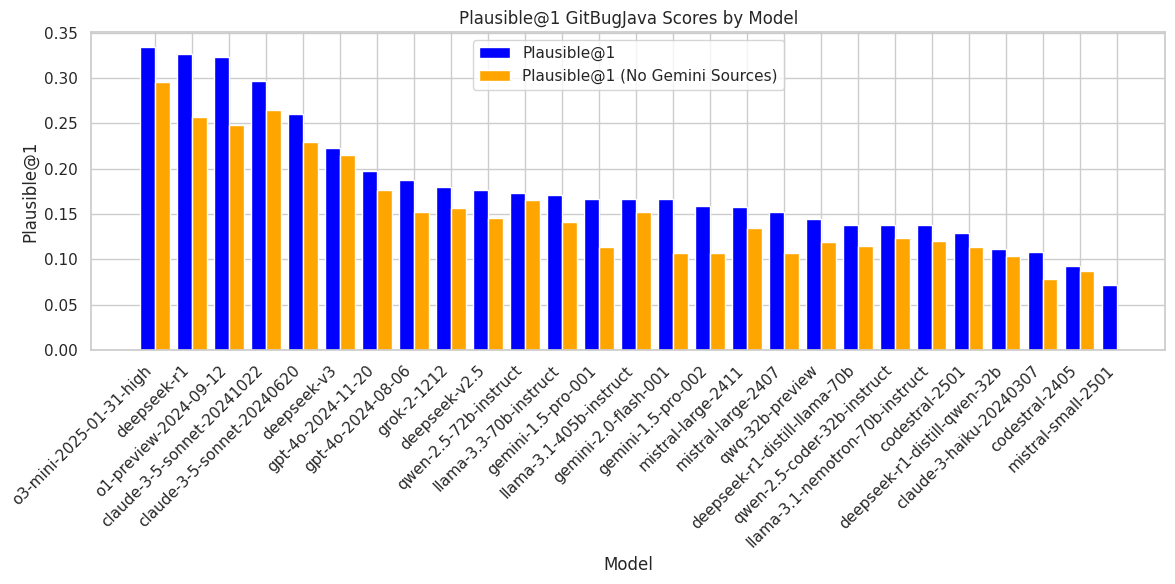

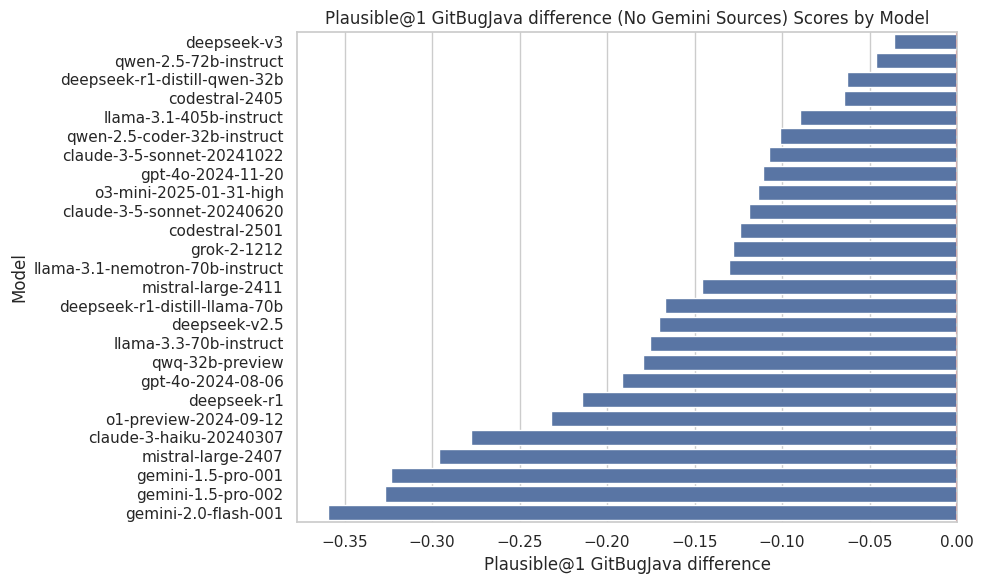

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read results.csv into a df

with open('results.csv', 'r') as f:
    data = pd.read_csv(f)

for benchmark in ["Defects4J", "GitBugJava"]:
    # "Plausible@1 [Benchmark]" and "Plausible@1 [Benchmark] (No Gemini Sources)" sorted by "Plausible@1 [Benchmark]" value from large to small
    # Single-bar plot where each blue bar is next to each orange bar for each model
    results_df = data.copy() 
    results_df = results_df.sort_values(by=f'Plausible@1 {benchmark}', ascending=False)
    results_df = results_df[results_df[f'Plausible@1 {benchmark}'].notna()]
    results_df = results_df.reset_index(drop=True)

    # Create the single-bar plot
    plt.figure(figsize=(12, 6))
    sns.set(style="whitegrid")

    # Create a bar plot with sns
    bar_width = 0.4
    indices = range(len(results_df))
    plt.bar(indices, results_df[f'Plausible@1 {benchmark}'], color='blue', label='Plausible@1', width=bar_width)
    plt.bar([i + bar_width for i in indices], results_df[f'Plausible@1 {benchmark} (No Gemini Sources)'], color='orange', label='Plausible@1 (No Gemini Sources)', width=bar_width)

    # Adjust x-axis ticks and labels
    plt.xticks([i + bar_width / 2 for i in indices], results_df['Model'], rotation=45, ha='right')
    plt.title(f'Plausible@1 {benchmark} Scores by Model')
    plt.xlabel('Model')
    plt.ylabel('Plausible@1')
    plt.legend()

    # Show the plot
    plt.tight_layout()
    # plt.savefig('plausible_at_1_benchmark.png')
    plt.show()

    # "Plausible@1 [Benchmark] (No Gemini Sources)" sorted by value from large to small
    results_df = results_df.sort_values(by=f'Plausible@1 {benchmark} (No Gemini Sources)', ascending=False)
    results_df = results_df[results_df[f'Plausible@1 {benchmark} (No Gemini Sources)'].notna()]
    results_df = results_df.reset_index(drop=True)

    # Create the single-bar plot for the difference
    results_df = data.copy() 
    results_df[f'Plausible@1 {benchmark} difference'] = (results_df[f'Plausible@1 {benchmark} (No Gemini Sources)'] - results_df[f'Plausible@1 {benchmark}']) / results_df[f'Plausible@1 {benchmark}']
    results_df = results_df.sort_values(by=f'Plausible@1 {benchmark} difference', ascending=False)
    results_df = results_df[results_df[f'Plausible@1 {benchmark} difference'].notna()]
    results_df = results_df.reset_index(drop=True)

    # Plot
    plt.figure(figsize=(10, 6))
    # Create a bar plot
    sns.barplot(x=f'Plausible@1 {benchmark} difference', y='Model', data=results_df)
    plt.title(f'Plausible@1 {benchmark} difference (No Gemini Sources) Scores by Model')
    plt.xlabel(f'Plausible@1 {benchmark} difference')
    plt.ylabel('Model')
    # Add a vertical line at 0
    plt.axvline(x=0, color='red', linestyle='--')

    # Show the plot
    plt.tight_layout()
    # plt.savefig('plausible_at_1_benchmark_no_gemini_sources.png')
    plt.show()

